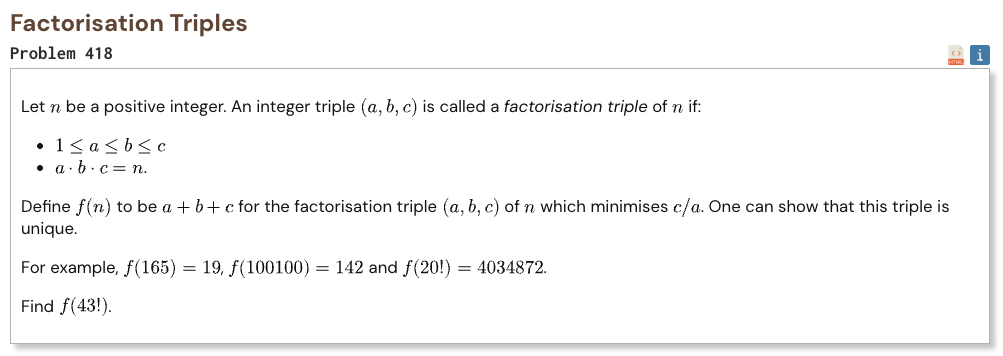

## Initial approach

-   factorise 43 factorial into its prime powers
-   the best three factors should be extremely close to each other
-   use the cube root of 43 factorial as the center of the search
-   generate only divisors that are very close to this cube root
-   try one divisor as the smallest factor and another as the largest factor
-   calculate the middle factor from the remaining part of 43 factorial
-   keep the valid triple with the smallest ratio between the largest and smallest factors
-   add the three factors to get the final result

In [1]:
import math
import bisect

def factorial_factors(n):
    primes = []

    for x in range(2, n + 1):
        is_prime = True

        for p in primes:
            if p * p > x:
                break
            if x % p == 0:
                is_prime = False
                break

        if is_prime:
            primes.append(x)

    exponents = []

    for p in primes:
        total = 0
        value = n

        while value:
            value //= p
            total += value

        exponents.append(total)

    return primes, exponents


def divisors_near_root(primes, exponents, low, high):
    suffix = [1] * (len(primes) + 1)

    for i in range(len(primes) - 1, -1, -1):
        suffix[i] = suffix[i + 1] * primes[i] ** exponents[i]

    divisors = []

    def build(i, value):
        if value > high:
            return

        if value * suffix[i] < low:
            return

        if i == len(primes):
            if low <= value <= high:
                divisors.append(value)
            return

        multiplier = 1

        for _ in range(exponents[i] + 1):
            build(i + 1, value * multiplier)
            multiplier *= primes[i]

    build(0, 1)

    return sorted(divisors)


n = math.factorial(43)
primes, exponents = factorial_factors(43)

root = n ** (1 / 3)

margin = 0.0001

candidates = divisors_near_root(
    primes,
    exponents,
    root * (1 - margin),
    root * (1 + margin)
)

middle = bisect.bisect_left(candidates, root)

best_a = 0
best_c = 1
best_triple = None

for a in candidates[:middle]:
    for c in candidates[middle:]:
        if best_triple is not None and c * best_a >= best_c * a:
            break

        if n % (a * c) != 0:
            continue

        b = n // (a * c)

        if a <= b <= c:
            best_a = a
            best_c = c
            best_triple = (a, b, c)
            break

In [2]:
%%time

result = sum(best_triple)
print("Result:", result)

Result: 1177163565297340320
CPU times: user 46 μs, sys: 5 μs, total: 51 μs
Wall time: 48.9 μs
